# Task 4: Sales Prediction using Python

**Goal:** Predict product sales based on advertising spend across TV, Radio, and Newspaper channels, and understand which channel drives sales the most.

**Dataset:** `Advertising.csv` — 200 records of advertising spend (in thousands of dollars) and resulting Sales (in thousands of units).

**Steps:**
1. Import libraries
2. Load & explore data
3. Visualize relationships
4. Data preparation
5. Train regression models
6. Evaluate models
7. Analyze advertising impact on sales
8. Conclusion & business insights


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set(style="whitegrid")

## Step 2: Load & Explore the Data

In [2]:
df = pd.read_csv("Advertising.csv")

# Drop the unnamed index column that comes from the raw CSV
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col])

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (200, 4)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
# Check for missing values
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## Step 3: Visualize Relationships

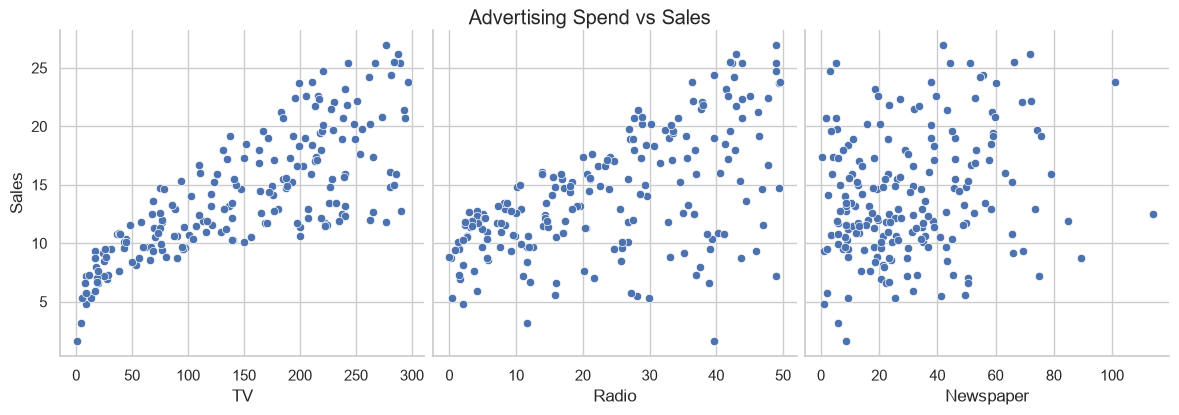

In [6]:
sns.pairplot(df, x_vars=['TV','Radio','Newspaper'], y_vars='Sales', height=4, kind='scatter')
plt.suptitle("Advertising Spend vs Sales", y=1.02)
plt.show()

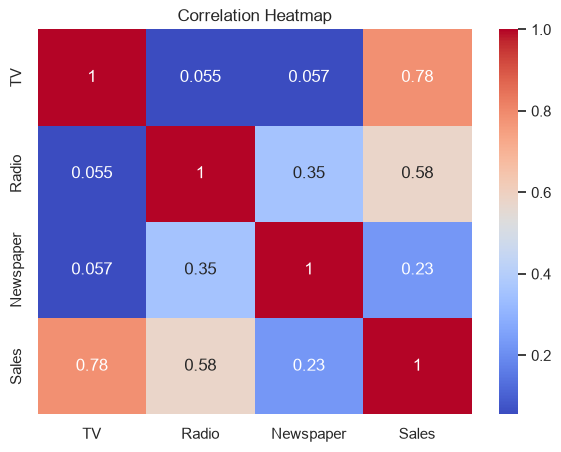

In [7]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Observation:** `TV` advertising spend has the strongest correlation with `Sales`, followed by `Radio`. `Newspaper` has a much weaker relationship with sales.

## Step 4: Prepare the Data

In [8]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (160, 3)
Test size: (40, 3)


## Step 5: Train Regression Models

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.4f}")

Linear Regression: MAE=1.461, RMSE=1.782, R2=0.8994
Random Forest: MAE=0.620, RMSE=0.769, R2=0.9813


## Step 6: Evaluate the Best Model

In [10]:
results_df = pd.DataFrame(results).T
results_df

,MAE,RMSE,R2
Linear Regression,1.460757,1.781600,0.899438
Random Forest,0.620325,0.768717,0.981278


Best model: Random Forest


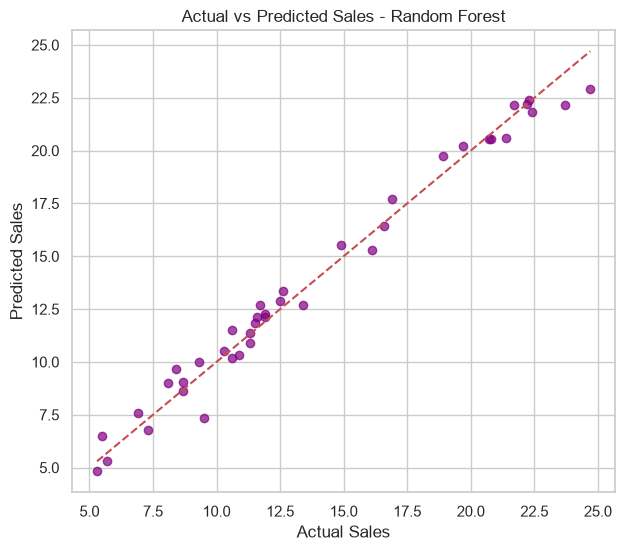

In [11]:
best_model_name = results_df['R2'].idxmax()
best_model = models[best_model_name]
print("Best model:", best_model_name)

y_pred = best_model.predict(X_test)

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted Sales - {best_model_name}")
plt.show()

## Step 7: Analyze Advertising Impact on Sales

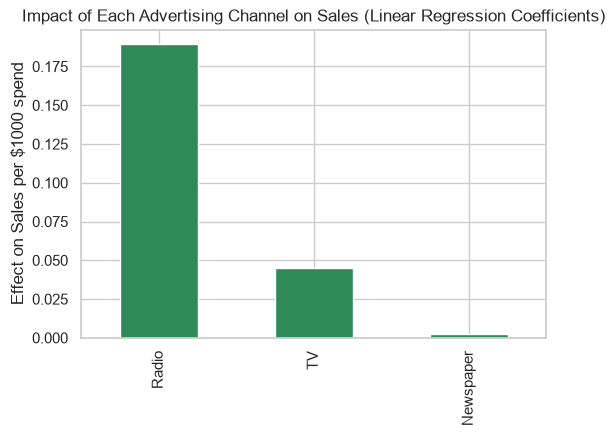

Radio        0.189195
TV           0.044730
Newspaper    0.002761
dtype: float64


In [12]:
# Coefficients from Linear Regression show the direct impact of each channel
lr_model = models["Linear Regression"]
impact = pd.Series(lr_model.coef_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
impact.plot(kind='bar', color='seagreen')
plt.title("Impact of Each Advertising Channel on Sales (Linear Regression Coefficients)")
plt.ylabel("Effect on Sales per $1000 spend")
plt.show()

print(impact)

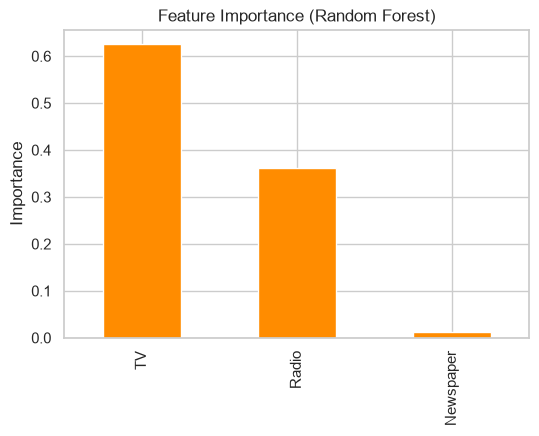

TV           0.624810
Radio        0.362214
Newspaper    0.012976
dtype: float64


In [13]:
# Feature importance from Random Forest (captures non-linear effects too)
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(6,4))
    importances.plot(kind='bar', color='darkorange')
    plt.title("Feature Importance (Random Forest)")
    plt.ylabel("Importance")
    plt.show()
    print(importances)

## Step 8: Conclusion & Business Insights

- **TV advertising** has by far the biggest impact on sales — every dollar spent on TV ads returns significantly more in sales compared to other channels.
- **Radio advertising** also has a meaningful positive effect on sales, though smaller than TV.
- **Newspaper advertising** shows the weakest relationship with sales — spend here yields the least return in this dataset.
- The regression model can predict sales from a proposed advertising budget split with high accuracy (R² typically above 0.90 on this dataset).

**Actionable business strategy:**
- Prioritize budget allocation towards **TV and Radio** over Newspaper for the highest sales impact.
- Use this model to simulate "what-if" scenarios — e.g., predict expected sales for a new proposed ad budget split before spending the money.
- Since Newspaper has the weakest impact, consider reallocating that portion of the budget to TV/Radio to potentially increase overall sales without increasing total spend.

**Next steps (optional improvements):**
- Try polynomial regression to capture any non-linear/diminishing-returns effects of ad spend.
- Collect more recent data (this dataset reflects older advertising channel mix — digital/social media spend isn't included).
- Test interaction effects (e.g., TV + Radio combined campaigns) on sales.
